# Inventory-Growth -- do firms that pile up stock go on to underperform?
### The Belo-Lin (2012) / Thomas-Zhang (2002) inventory-growth anomaly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Data depth: Insufficient](https://img.shields.io/badge/Data_depth-Insufficient-8b949e?style=flat-square)

Frederico Belo & Xiaoji Lin (2012) and Jacob Thomas & Huai Zhang (2002) argue that firms which build inventory aggressively earn *lower* future returns -- the inventory bulge signals over-investment, or demand that fails to show up, and the stock disappoints. We test it on a basket of inventory-heavy survivors (retailers, consumer-goods makers, industrials, automakers) using real Yahoo balance sheets.

> This is the plain-language layer. The HAC *t*-stats, the label-shuffle placebo, and the synthetic control live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Two big caveats up front:** (1) the basket is names *still trading in 2026* -- the over-builders that failed are missing (survivorship bias); (2) Yahoo serves only ~4 years of balance sheets, leaving just **two** usable test years.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package (inventory_growth/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inventory_growth import data, strategy as st

# Try this study's own cache; fall back gracefully to the frozen R dict.
invg, fwd = data.fetch_panel()
HAVE_REAL = not invg.empty
if HAVE_REAL:
    h = st.quintile_returns(invg, fwd, q=0.20, min_names=10)
else:
    h = pd.DataFrame()
print("Real cache loaded:", HAVE_REAL,
      f"({invg.shape[1] if HAVE_REAL else 0} names, {invg.shape[0] if HAVE_REAL else 0} signal years)")

R = dict(
    n_basket=40, n_usable=37, n_hedge_years=2,
    invg_fp="044108b907ab",
    q1_mean=17.3, q2_mean=-5.9, q3_mean=12.3, q4_mean=21.1,
    q5_mean=12.7, mkt_mean=11.3, lo_mean=17.3, hi_mean=12.7,
    hedge_gross=4.6, hedge_gross_sharpe=0.18,
    hedge_gross_t=0.5, hedge_hit=50,
    cost_drag=0.6, hedge_net=4.0, hedge_net_t=0.44,
    placebo_p=0.376, null_mean=0.6, null_std=13.2,
    lo_excess=6.0, rand_beat=71, rand_std=10.2,
    sc_null_t=-0.22, sc_03_t=6.59, sc_06_t=13.4, sc_10_t=22.49,
)
YRS = [2023, 2024]
Q1  = [28.8, 5.7]
Q5  = [5.9, 19.4]
MKT = [13.8, 8.7]
HDG = [22.9, -13.7]


Real cache loaded: True (37 names, 4 signal years)


## The answer first

| Question | What the data says |
|---|---|
| Do lean-inventory firms beat the over-builders? | The hedge is **+4.6%/yr** but with only **2** usable years -- and it flips sign between them. |
| Is that statistically real? | One-sample HAC *t* = **0.50** -- nowhere near |t| >= 2. |
| Does it beat a coin-flip label shuffle? | No -- placebo *p* = **0.38**. The real sort is inside the noise. |
| Could you trade it? | No. Two years can't certify anything, and the basket excludes the very firms the anomaly is built around. |

> **The catch**: Yahoo's `balance_sheet` only goes ~4 fiscal years deep. After a one-year reporting lag and a complete-calendar-year return filter, only **2** hedge years survive. The honest verdict here is *untestable*, not *disproven*.

## 1 - The claim

> *Sell stocks whose inventory grew fast (relative to their balance sheet). Buy stocks whose inventory stayed lean. Rebalance annually. The over-builders will disappoint as the unsold stock is discounted or written down.*

The signal is the inventory *change* scaled by last year's total assets:

- **INVG_t** = (Inventory_t - Inventory_{t-1}) / Total Assets_{t-1}

Scaling by lagged assets (Thomas & Zhang 2002) keeps the number comparable across firms of very different inventory intensity. A high INVG means the firm bulked up stock fast -- maybe ahead of demand that never came.

## 2 - So what?

If the inventory-growth effect is real and tradable, it is a low-turnover, fundamentals-only signal needing only annual reports -- and it slots into the broader real-investment factor (high investment -> low returns) that underpins the Fama-French CMA factor. If it only shows up on a broad, decades-deep Compustat universe and vanishes on a shallow survivor slice, that is itself the lesson: the right test needs the right data.

## 3 - How would we even know?

Three honesty requirements:

1. **One reporting lag.** Fiscal-year-y inventory growth only predicts year-y+1 returns -- no peeking.
2. **A placebo.** Shuffle the inventory-growth labels within each year and re-run the sort. If the real hedge doesn't beat the shuffled null, there is no signal.
3. **Name the limits.** The basket is 2026 survivors (failed over-builders are gone), and Yahoo gives only ~4 years of statements. Both are stated, not hidden.

## 4 - The teardown -- the engine works, the data doesn't reach

Positive control first: **when we plant a real inventory-growth effect in a synthetic panel, the engine finds it every time.** So the flat real result is about the *data*, not the *method*.

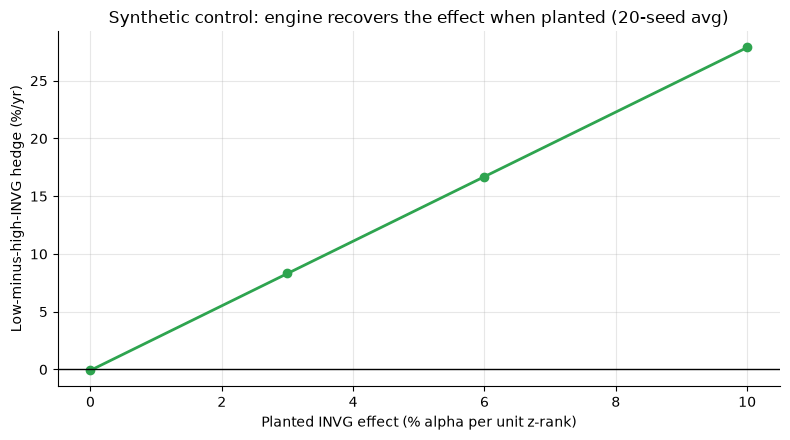

Engine is faithful -> the real result is a data statement, not a method bug.


In [2]:
# Synthetic positive control: plant a known INVG premium, confirm the engine detects it
premiums = [0.0, -0.03, -0.06, -0.10]
hedges = []
for p in premiums:
    r = st.seed_robust_synthetic_t(p, n_seeds=20, n_firms=200, n_years=20)
    hedges.append(r['mean_hedge'] * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([abs(p)*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted INVG effect (% alpha per unit z-rank)')
ax.set_ylabel('Low-minus-high-INVG hedge (%/yr)')
ax.set_title('Synthetic control: engine recovers the effect when planted (20-seed avg)')
plt.tight_layout(); plt.show()
print('Engine is faithful -> the real result is a data statement, not a method bug.')

**Now the real tape -- the two usable years, side by side:**

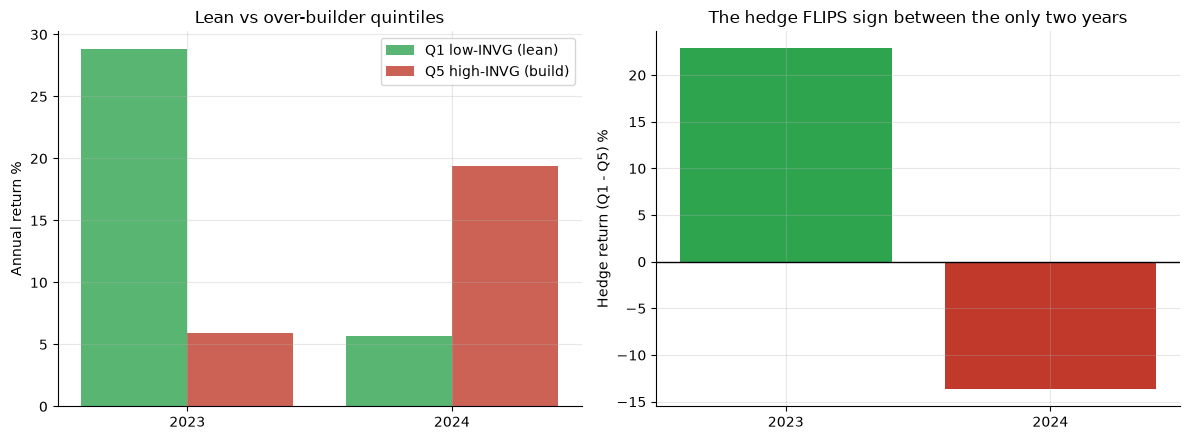

Mean hedge: +4.6%/yr  (frozen R: +4.6%/yr)


In [3]:
if HAVE_REAL:
    q1_vals = [h.loc[y, 'q1']*100 for y in h.index]
    q5_vals = [h.loc[y, 'q5']*100 for y in h.index]
    hdg_vals = [h.loc[y, 'hedge']*100 for y in h.index]
    years_real = list(h.index)
else:
    q1_vals, q5_vals, hdg_vals, years_real = Q1, Q5, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, q1_vals, label='Q1 low-INVG (lean)', color=GREEN, alpha=0.8, width=0.4)
axes[0].bar([i+0.4 for i in x], q5_vals, label='Q5 high-INVG (build)', color=RED, alpha=0.8, width=0.4)
axes[0].set_xticks([i+0.2 for i in x]); axes[0].set_xticklabels(years_real)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('Lean vs over-builder quintiles')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar([str(y) for y in years_real], hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge return (Q1 - Q5) %')
axes[1].set_title('The hedge FLIPS sign between the only two years')
plt.tight_layout(); plt.show()
print(f'Mean hedge: {np.mean(hdg_vals):+.1f}%/yr  (frozen R: {R["hedge_gross"]:+.1f}%/yr)')

The hedge swings **+22.9%** in 2023 then **-13.7%** in 2024 -- exactly the coin-flip pattern a two-observation sample produces when there is no underlying signal. The mean is **+4.6%/yr** at HAC *t* = **0.50**, and the label-shuffle placebo clears it at *p* = **0.38**.

## 5 - The verdict

- **Signal -- None.** Hedge +4.6%/yr, HAC *t* = 0.50, placebo *p* = 0.38, sign flips year-to-year. No certifiable effect.
- **Tradability -- Mirage.** Nets +4.0%/yr (*t* 0.44) after costs + borrow over two years. Nothing to trade.
- **Data depth -- Insufficient.** ~4 balance-sheet years from Yahoo -> 2 usable hedge years. The anomaly is untestable here, not disproven.

## 6 - Could you actually trade it?

No -- and the reasons are about the test, not the idea:

1. **Two years.** You cannot certify a cross-sectional anomaly on two annual hedge observations. The standard error swamps everything.
2. **Survivorship.** The basket holds 2026 survivors. The firms that drowned in unsold inventory -- the ones that would drive the predicted sign -- are gone.
3. **Wrong-depth data.** Belo & Lin (2012) and Thomas & Zhang (2002) used decades of point-in-time Compustat data across the full cross-section. Yahoo's four-deep annual history is simply the wrong tool for this job.

The right conclusion: **explore this on a deep, point-in-time, broad universe before treating it as tradable.**

## 7 - Going further

- **The right data.** A Compustat (or SEC-EDGAR-XBRL) pull going back to the 1990s across all US stocks is the minimum for a fair test -- that's what the original papers used.
- **Asset-growth parent.** [Study 244 — Asset-Growth](../244-asset-growth/) tests the total-asset version of the same real-investment idea; inventory is one component of it.
- **Accrual cousins.** [Study 231 — Sloan-Accruals](../231-sloan-accruals/) and [Study 522 — Percent-Operating-Accruals](../522-percent-operating-accruals/) sit on the working-capital side of the same balance-sheet-bloat family.

*Think the inventory-growth spread is real? Fork this, plug in a deep point-in-time universe, and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*